# Week 04 - Lesson 01: Observability

This notebook introduces **Observability** in AI applications using LangSmith, a comprehensive platform for monitoring, debugging, and optimizing LLM applications. Observability is crucial for enterprise AI systems to ensure reliability, performance, and continuous improvement.


<img src="https://cdn.prod.website-files.com/675151245f2993547dbd5046/680a11951cf22ec1895665d1_LLM%20Observability%20with%20LangSmith.webp" alt="LangSmith Observability Overview" width="700"/>

### **Learning Objectives**
By the end of this notebook, you will:
1. Understand the fundamentals of observability in AI applications
2. Learn how to implement tracing and monitoring with LangSmith
3. Master feedback collection and evaluation techniques
4. Implement production monitoring and alerting systems

#### **Why Observability Matters**

Observability in AI applications provides:

- **Performance Monitoring**: Track response times, token usage, and system performance
- **Quality Assurance**: Monitor response quality and user satisfaction
- **Cost Management**: Track API usage and optimize resource consumption
- **Debugging**: Identify and resolve issues quickly
- **Compliance**: Maintain audit trails and regulatory compliance

#### **Get Your LangSmith API Key**

Visit https://smith.langchain.com and create an account to get your API key.

## 1. Environment Setup and Dependencies

First, let's ensure we have all necessary dependencies installed and configured.


In [1]:
# Install required dependencies
%pip install -U --quiet langsmith langchain langchain-openai python-dotenv openai

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage
from langsmith import Client, traceable

In [20]:
# Load environment variables
load_dotenv()

# Set up LangSmith environment variables
os.environ['LANGSMITH_TRACING'] = 'true' # You need to set this to true to trace the model.
os.environ['LANGSMITH_API_KEY'] = 'ls_api_key'
os.environ['LANGSMITH_PROJECT'] = 'my-project-observability'
os.environ['OPENAI_API_KEY'] = 'sk-proj-your-api-key'

# OpenAI API Key
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

## 2. Understanding Observability Concepts

### Core Observability Pillars

1. **Tracing**: Track the flow of requests through your AI system
2. **Logging**: Record detailed information about system behavior
3. **Feedback**: Capture feedback and quality metrics associated with each run.

### LangSmith Capabilities

- **Automatic Tracing**: Track LLM calls and chains
- **Custom Metadata**: Add business context metadata to traces
- **Feedback Collection**: Capture user feedback
- **Monitoring Dashboards**: Visualize system performance
- **A/B Testing**: Compare different model configurations

---

## 3. Understanding Tracing Approaches

Two Different Approaches for Tracing

> **1. Raw OpenAI Client (requires wrapper):**

```python
from openai import OpenAI
from langsmith.wrappers import wrap_openai

# Create raw OpenAI client
openai_client = OpenAI()

# Wrap it for automatic tracing
traced_client = wrap_openai(openai_client)

# Use the wrapped client for API calls
response = traced_client.chat.completions.create(...)
```

> **2. LangChain Models (automatic tracing):**

```python
from langchain_openai import ChatOpenAI

# Set environment variables
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_API_KEY'] = 'your-api-key'
os.environ['LANGSMITH_PROJECT'] = 'your-project'

# LangChain models are automatically traced
chat_model = ChatOpenAI(model="gpt-4o-mini")
response = chat_model.invoke(messages)  # Automatically traced!
```

> Key Differences

- **Raw OpenAI**: Requires explicit wrapping with `wrap_openai()`
- **LangChain**: Automatic tracing when environment variables are set


## 4. Basic Tracing Implementation

In [4]:
# Create client
client = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=OPENAI_API_KEY,
    temperature=0.1,
    max_tokens=1000
)

# If you want to trace the OpenAI client, you can use the following code:
# from langsmith.wrappers import wrap_openai
# openai_client = wrap_openai(OpenAI()) # <------ IMPORTANT: This is the client that will be traced.
# wrap_openai wraps the OpenAI client so that all API calls are automatically traced in LangSmith. 

In [5]:
# Create a simple function to be traced
@traceable
def analyze_business_scenario(scenario: str, industry: str) -> str:
    """Analyze a business scenario with observability."""
    
    system_prompt = f"""You are a senior business analyst specializing in {industry}.
    Provide a structured analysis with:
    1. Key Insights
    2. Risk Assessment
    3. Strategic Recommendations
    4. Implementation Timeline"""
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Analyze this scenario: {scenario}")
    ]
    
    response = client.invoke(messages)
    return response.content

In [6]:
# Test the traced function
try:
    scenario = "A mid-sized manufacturing company is considering expanding into international markets. They have strong domestic sales but limited experience with global operations."
    
    print(scenario)
    print("\n" + "="*80 + "\n")
    
    result = analyze_business_scenario(
        scenario=scenario,
        industry="manufacturing and international business"
    )
    
    print("Analysis Results:")
    print(result)
    
except Exception as e:
    print(f"Error: {e}")
    print("\nMake sure you have set your API keys correctly!")


A mid-sized manufacturing company is considering expanding into international markets. They have strong domestic sales but limited experience with global operations.


Analysis Results:
### Structured Analysis for International Expansion of a Mid-Sized Manufacturing Company

#### 1. Key Insights
- **Market Potential**: The global manufacturing market is projected to grow significantly, with emerging markets offering substantial opportunities due to rising demand for manufactured goods.
- **Competitive Landscape**: The company may face competition from established local players in target markets, as well as other international firms. Understanding local competitors and their strategies will be crucial.
- **Regulatory Environment**: Different countries have varying regulations regarding manufacturing, labor laws, tariffs, and trade agreements. Compliance will be a significant factor in successful market entry.
- **Cultural Differences**: Cultural nuances can affect consumer behavior, mar

## 5. Check Your Traces in LangSmith

Now that you've run the code, you should see traces automatically appearing in LangSmith. Visit [https://smith.langchain.com](https://smith.langchain.com) and open your project `my-project-observability` to view the execution traces.

You'll see a list of runs where each call to `analyze_business_scenario()` appears as a separate trace. Click any trace to see detailed information including performance metrics, inputs and outputs, and metadata about the model configuration.

The traces will show you execution times, token usage, the prompts sent to the model, and the responses generated. This gives you complete visibility into how your AI system is performing and allows you to monitor quality and optimize performance over time.

If you don't see traces appearing, verify that your environment variables are set correctly, particularly `LANGSMITH_TRACING=true` and that your LangSmith API key is valid.

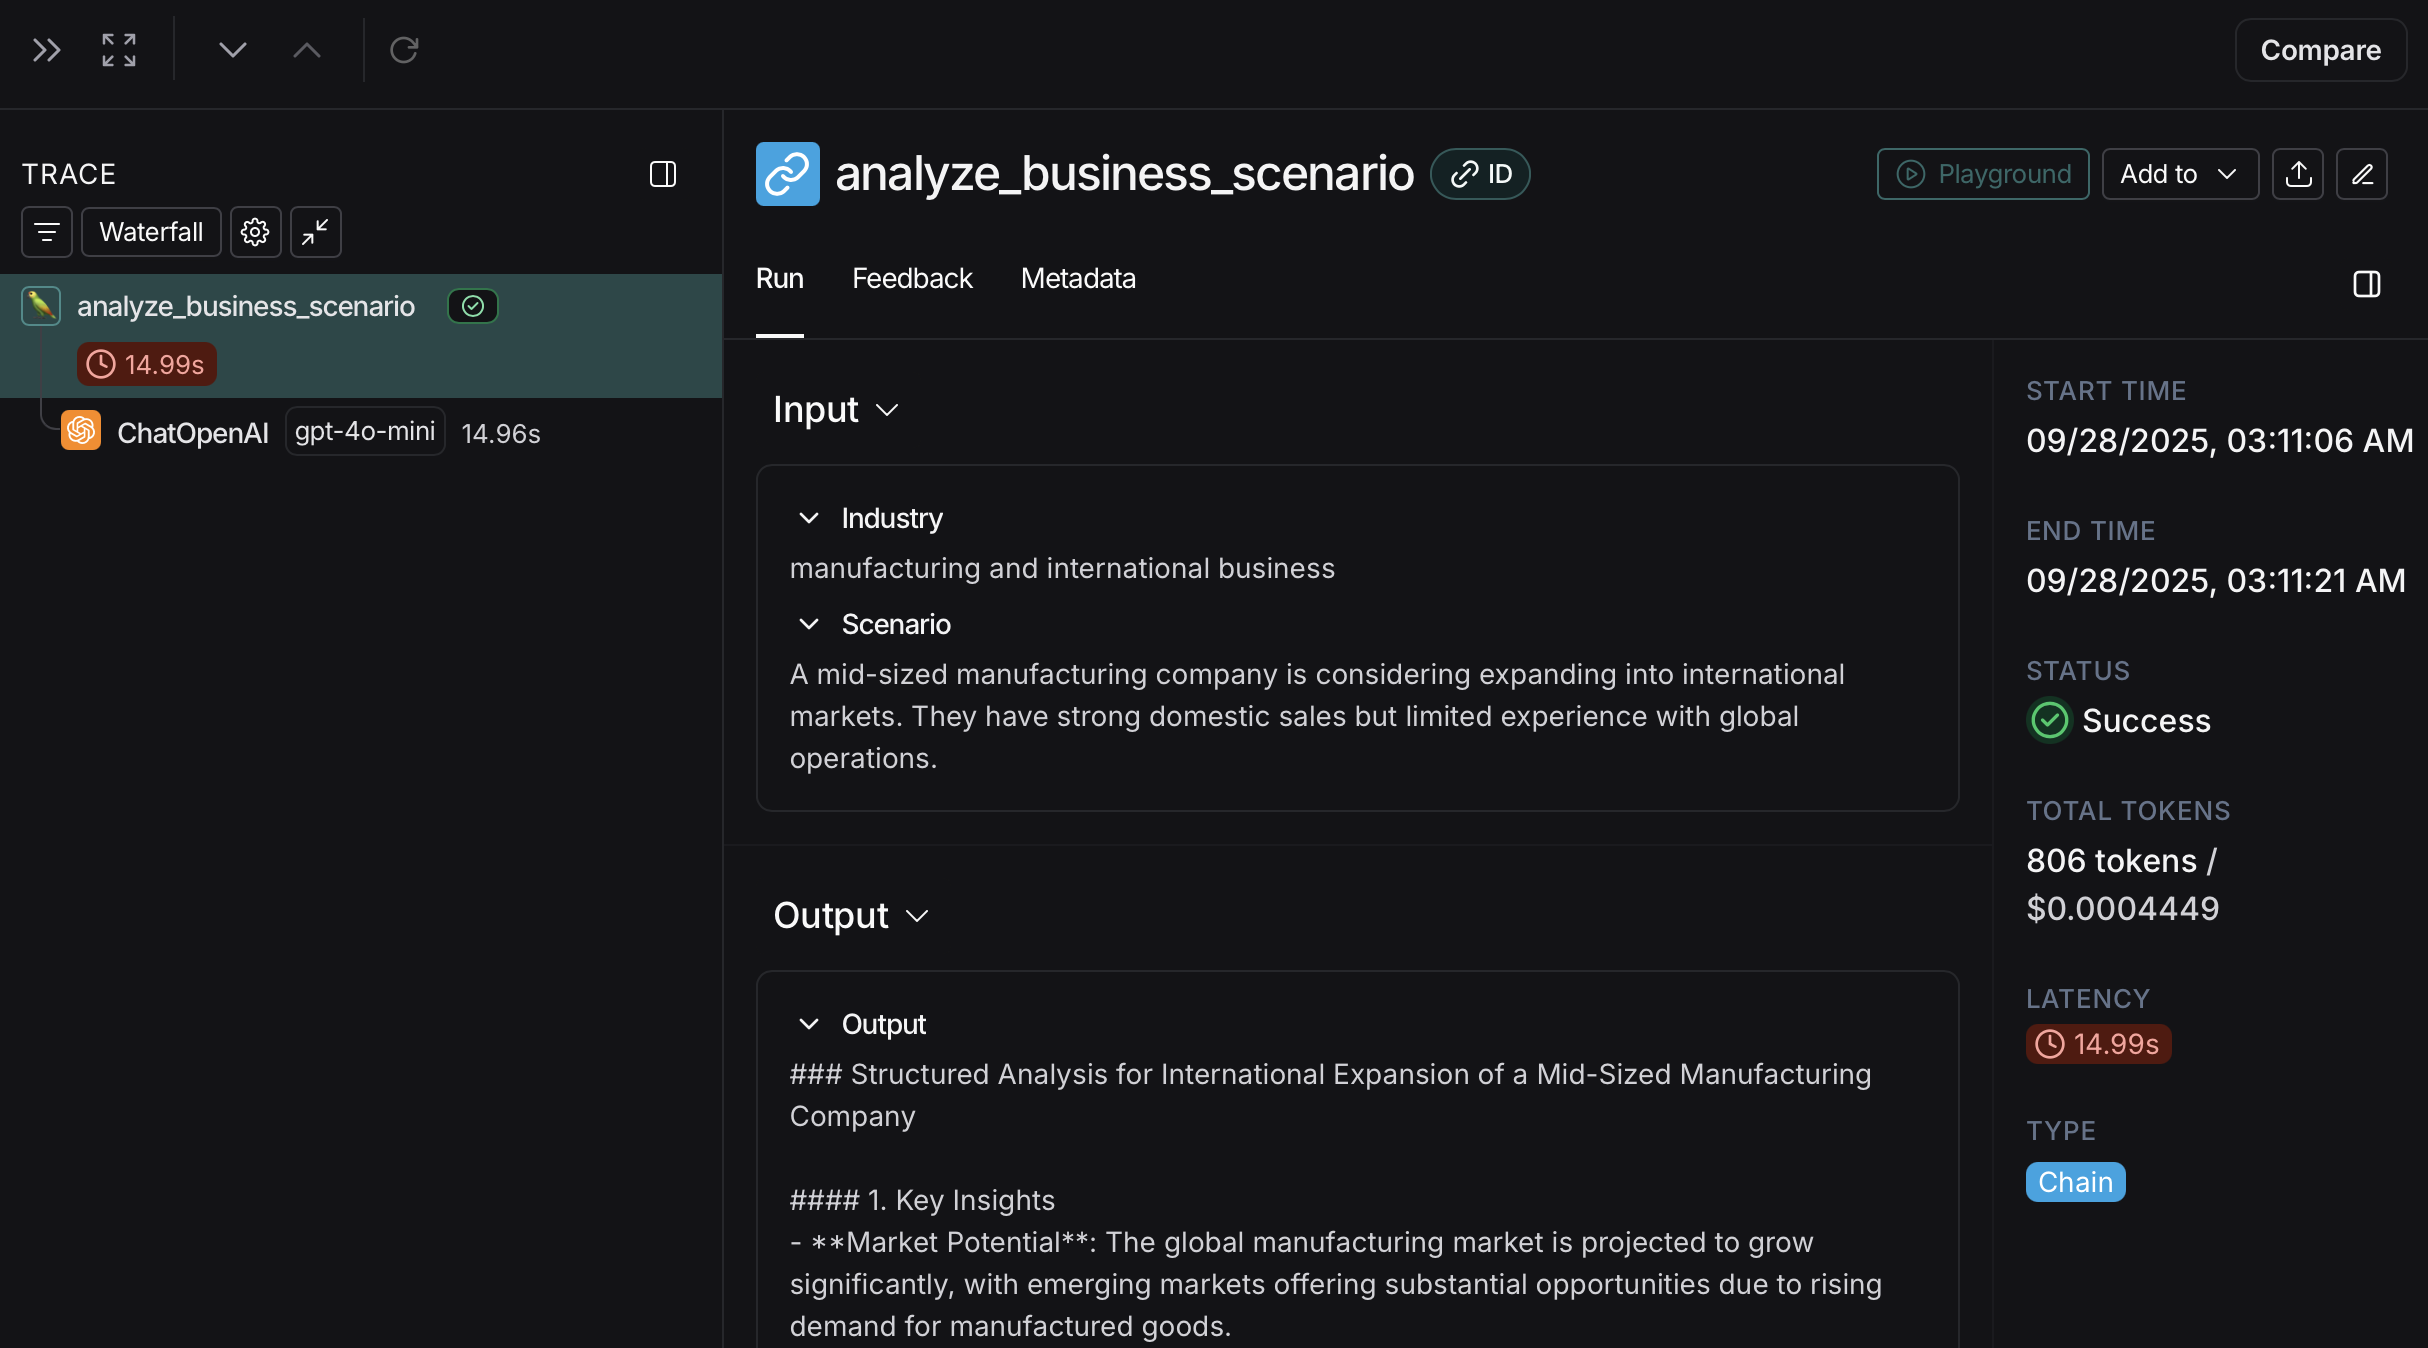

In [7]:
# Printing example of trace
import os
from IPython.display import Image, display

notebook_dir = os.path.dirname(os.path.abspath(''))

image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_01.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

## 6. Tracing with Metadata

Adding business context and metadata to traces for better observability.


In [8]:
# Enhanced tracing with metadata
@traceable(
    metadata={
        "service": "business_analysis",
        "version": "2.0",
    }
)
def enhanced_business_analysis(
    scenario: str, 
    industry: str, 
    department: str = None
) -> str:
    """Enhanced business analysis with comprehensive metadata."""

    system_prompt = f"""You are a senior business analyst specializing in {industry}.
    
    Context:
    - Department: {department or 'General'}
    
    Provide a comprehensive analysis with:
    1. Executive Summary
    2. Key Insights
    3. Risk Assessment
    4. Strategic Recommendations
    5. Implementation Timeline
    6. Success Metrics"""
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Analyze this business scenario: {scenario}")
    ]
    
    response = client.invoke(messages)
    return response.content

In [9]:
# Add runtime metadata
import uuid
run_id = str(uuid.uuid4())

enhanced_business_analysis(
    scenario = "A financial services company wants to implement AI-powered fraud detection. They process 1M transactions daily and need 99.9% accuracy.",
    industry = "financial services",
    department = "Risk Management",
    langsmith_extra = {
        "run_id": run_id,
        "metadata": {
            "user_id": "user_001",
        }
    }
)

"### Executive Summary\nThe financial services company is poised to implement an AI-powered fraud detection system to enhance its risk management capabilities. With a daily processing volume of 1 million transactions, achieving a fraud detection accuracy of 99.9% is critical to minimize financial losses and maintain customer trust. This analysis outlines the key insights, risk assessment, strategic recommendations, implementation timeline, and success metrics for the proposed AI solution.\n\n### Key Insights\n1. **Transaction Volume**: The company processes a substantial volume of transactions daily, necessitating a robust and scalable AI solution capable of real-time analysis.\n2. **Fraud Trends**: Fraud tactics are evolving, with increasingly sophisticated methods being employed by fraudsters. Traditional detection methods may not suffice.\n3. **Data Quality**: The effectiveness of AI models is heavily dependent on the quality and quantity of historical transaction data. Clean, label

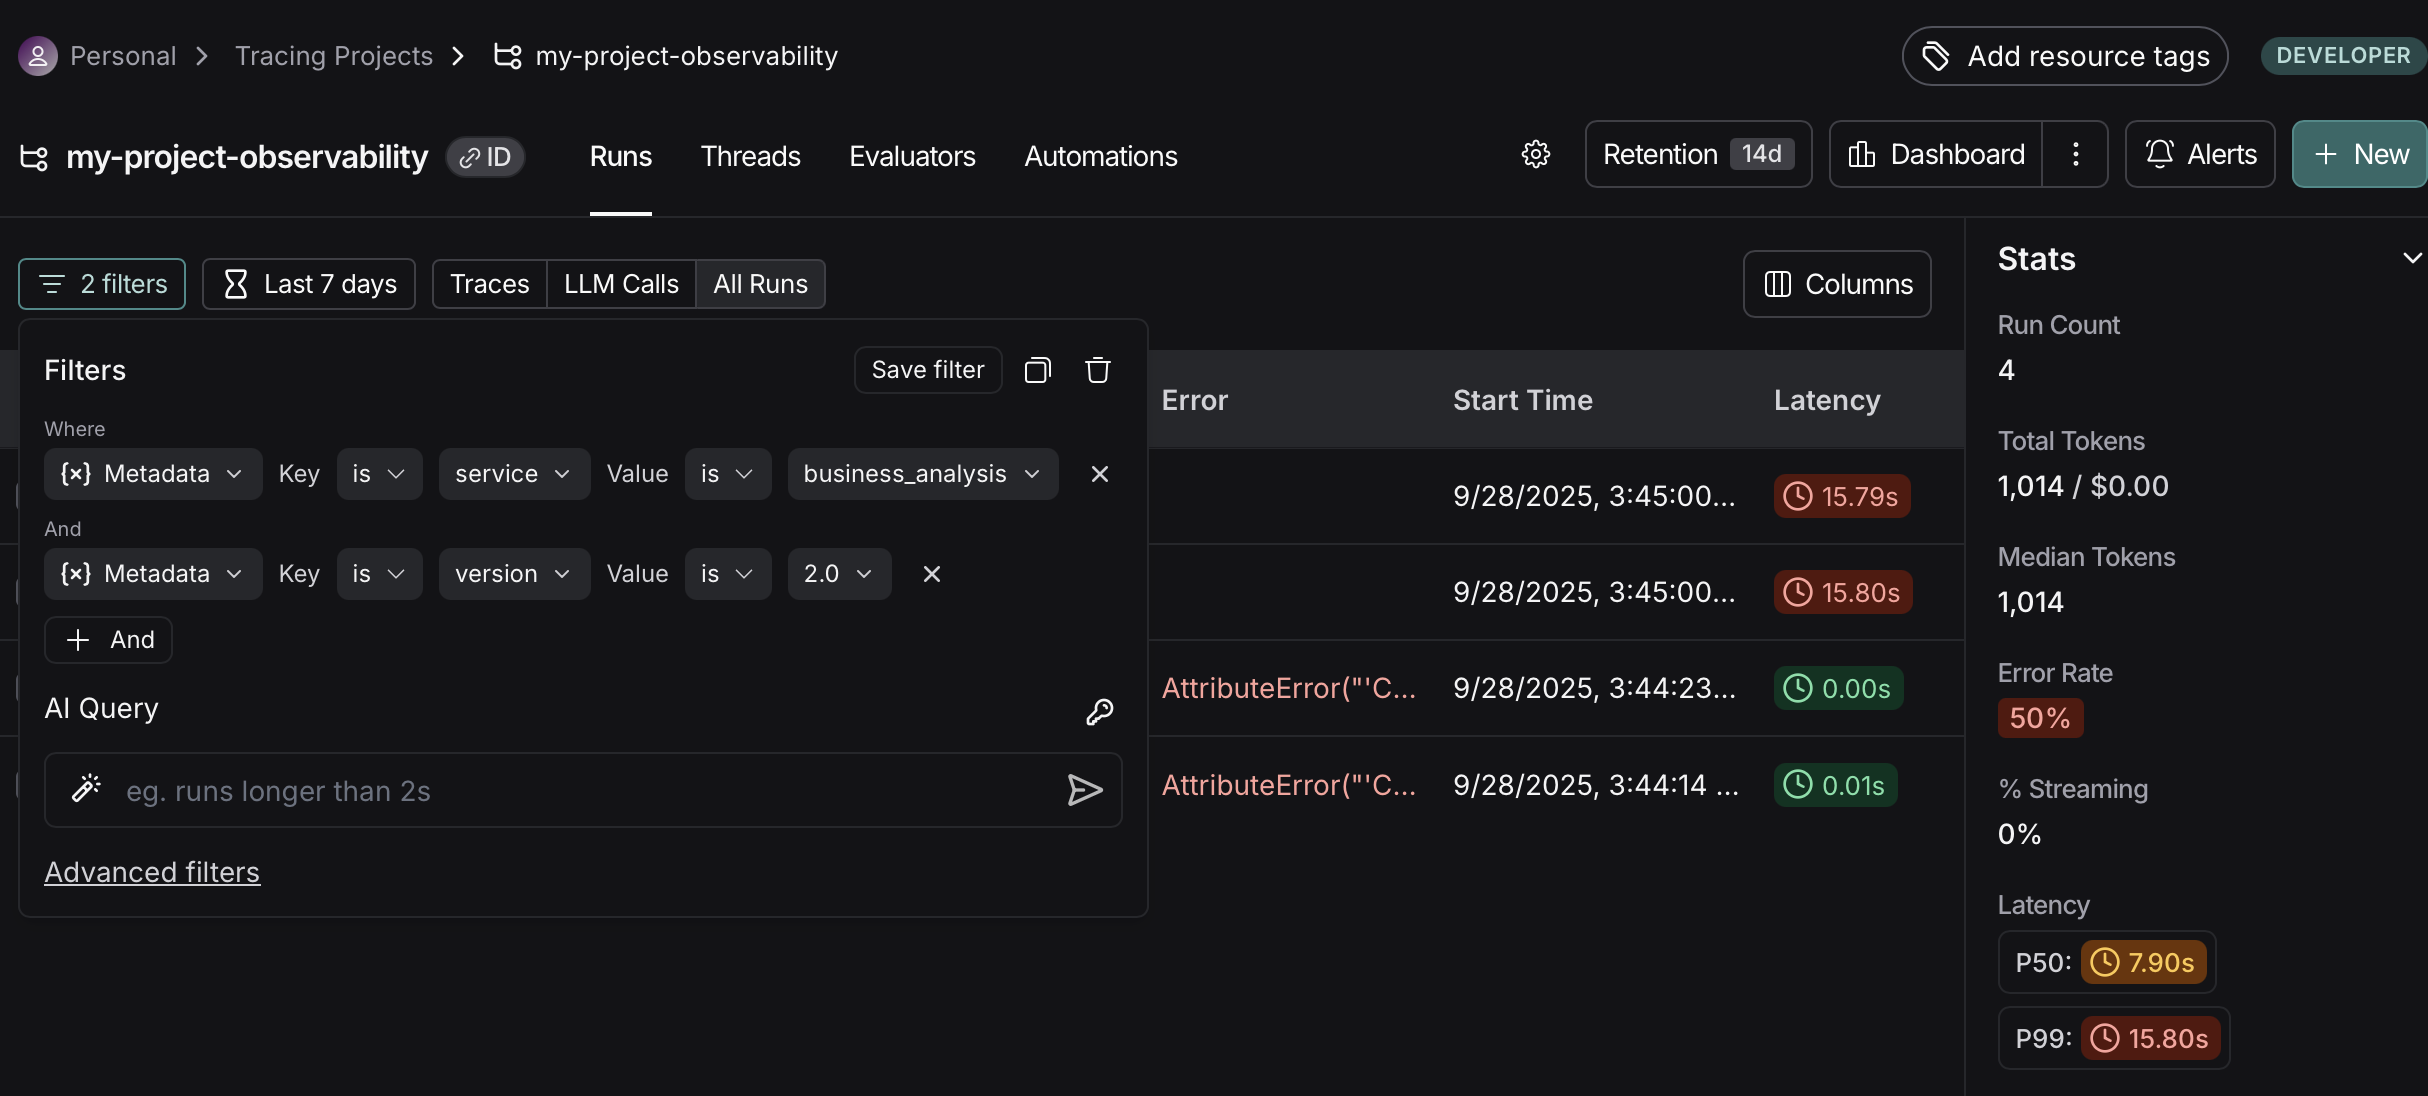

In [18]:
# Printing example of trace with metadata filter
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_02.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

## 7. Feedback Collection System

Implementing user feedback collection for continuous improvement.


In [11]:
from langsmith import Client

# Initialize LangSmith client for feedback collection
ls_client = Client()

def collect_user_feedback(run_id: str, score: float, comment: str = None):
    ls_client.create_feedback(
        run_id,
        key="user-score-satisfaction",
        score=score,
        comment=comment
    )

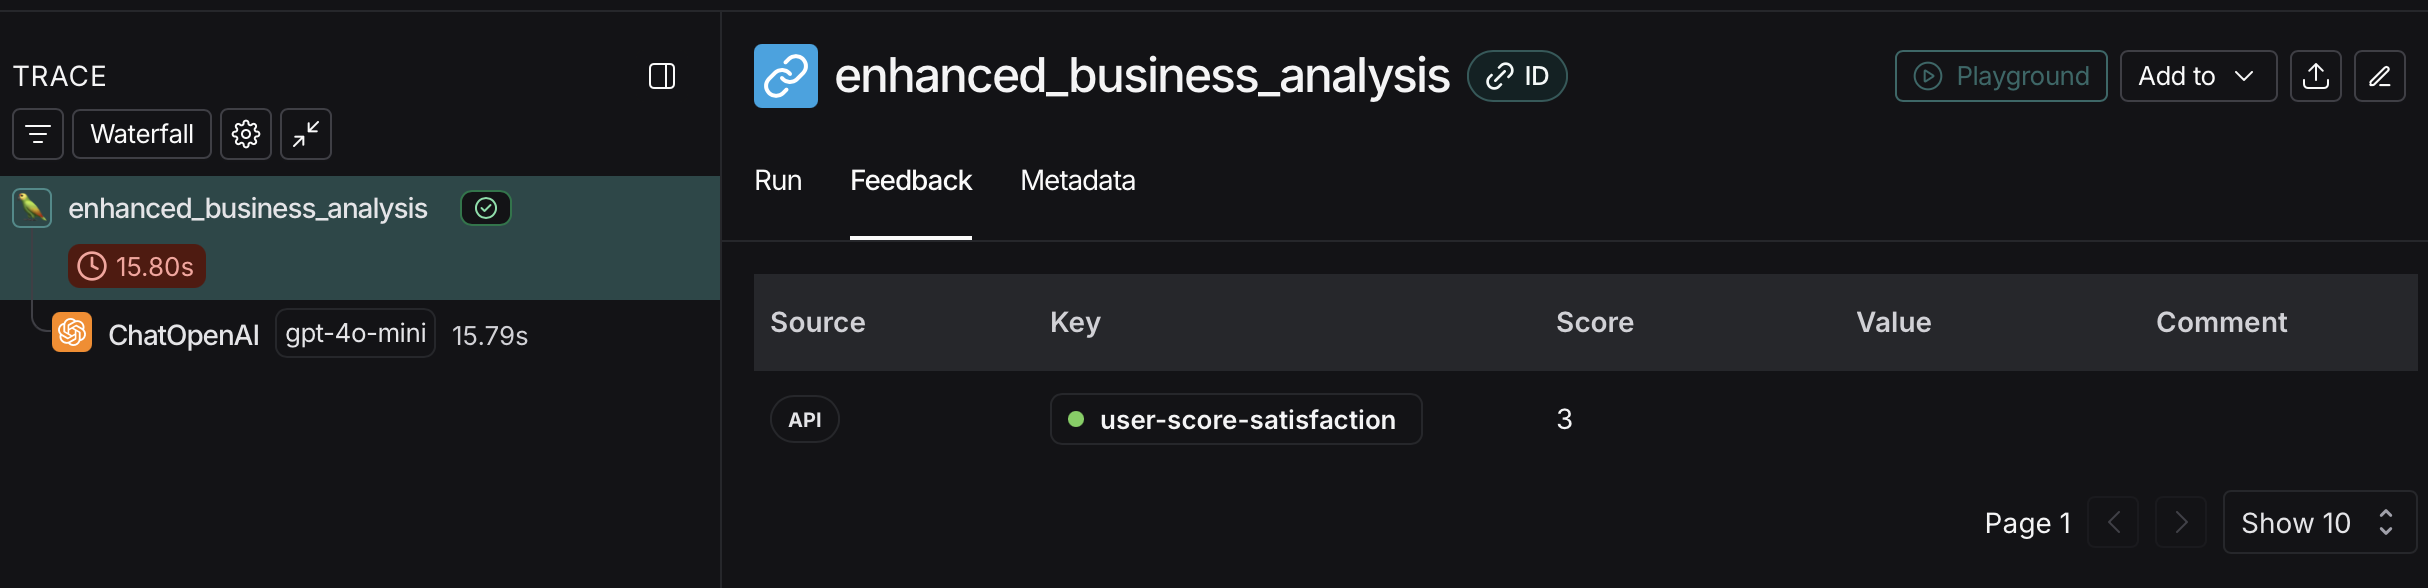

In [ ]:
# Printing example of trace with feedback collection
image_path = os.path.join(notebook_dir, 'week_04', 'images', 'example_03.png')

if os.path.exists(image_path):
    display(Image(image_path))
else:
    print(f"Image not found at: {image_path}")

In [17]:
# Test the complete system
try:
    scenario = "A healthcare company wants to implement AI for patient diagnosis assistance. They handle 10,000 patients monthly and need to maintain 99.5 percent of accuracy."
    print(scenario)
    print("\n" + "="*80 + "\n")
    
    run_id = str(uuid.uuid4())

    result = enhanced_business_analysis(
        scenario = scenario,
        industry="healthcare and AI",
        department = "R&D",
        langsmith_extra = {
            "run_id": run_id,
            "metadata": {
                "user_id": "user_001",
            }
        }
    )

    print("Analysis Results:")
    print(result)

    collect_user_feedback(
        run_id=run_id,
        score=4.5,
        comment="Excellent analysis with actionable insights"
    )
    
except Exception as e:
    print(f"Error: {e}")


A healthcare company wants to implement AI for patient diagnosis assistance. They handle 10,000 patients monthly and need to maintain 99.5 percent of accuracy.


Analysis Results:
### Executive Summary
The healthcare company aims to implement an AI-driven patient diagnosis assistance system to enhance diagnostic accuracy and efficiency. With a patient volume of 10,000 monthly and a target accuracy of 99.5%, the integration of AI can significantly improve patient outcomes, reduce diagnostic errors, and streamline operational processes. This analysis outlines key insights, risks, strategic recommendations, an implementation timeline, and success metrics to ensure a successful deployment of the AI system.

### Key Insights
1. **Market Demand**: There is a growing demand for AI in healthcare, particularly in diagnostics, as it can process vast amounts of data quickly and identify patterns that may be missed by human practitioners.
2. **Current Diagnostic Challenges**: The healthcare compan

## 8. Monitoring

You can also use LangSmith to monitor your project in real time. By clicking on the `Monitor` tab, you’ll see charts with important LLM statistics such as the number of traces, feedback collected, and time-to-first-token.

These charts can be viewed across different time intervals, helping you understand how your system behaves over time.

<img src="https://mintcdn.com/langchain-5e9cc07a/1RIJxfRpkszanJLL/langsmith/images/tracing-tutorial-monitor.png?w=1100&fit=max&auto=format&n=1RIJxfRpkszanJLL&q=85&s=848482d02d40236a1911a9623c39a2f0" alt="LangSmith Monitoring Screenshot" style="width:600px; height:auto;">

## 9. A/B Testing

LangSmith can also be used for A/B testing experiments. With the Group-by functionality, you can compare performance across different values of a chosen metadata key (for example, comparing two different LLMs, prompts, or versions).

To do this, you simply click the `Metadata` button and select the attribute you want to group by.
Once selected, the monitoring charts will update to show grouped results, making it easy to see which variant performs better over time.

<img src="https://mintcdn.com/langchain-5e9cc07a/1RIJxfRpkszanJLL/langsmith/images/tracing-tutorial-monitor-metadata.png?w=1100&fit=max&auto=format&n=1RIJxfRpkszanJLL&q=85&s=73662cff14eebb9498e295834e6b8c86" alt="LangSmith A/B Testing Monitoring Screenshot" style="width:600px; height:auto;">

## 10. Drilldown

Another powerful feature is the ability to drill down into specific datapoints. While exploring the monitoring charts, you can hover over a datapoint and click it. This action will take you back to the runs table, already filtered to show only the runs that contributed to that datapoint.
This makes it simple to investigate issues, anomalies, or unexpected behaviors.

<img src="https://mintcdn.com/langchain-5e9cc07a/ImHGLQW1HnQYwnJV/langsmith/images/tracing-tutorial-monitor-drilldown.png?w=1100&fit=max&auto=format&n=ImHGLQW1HnQYwnJV&q=85&s=8ce416eec3bdc7b4289ba9fbedf6959a" alt="LangSmith Drilldown Monitoring Screenshot" style="width:600px; height:auto;">


## 11. Key Takeaways

### What We've Accomplished

1. **Basic Tracing**: Implemented automatic tracing for LLM calls
2. **Metadata Enhancement**: Added business context to traces
3. **Feedback Collection**: Built user feedback systems
4. **Production Monitoring**: Created production-ready monitoring patterns

### Enterprise Benefits

- **Performance Optimization**: Track and optimize system performance
- **Quality Assurance**: Monitor response quality and user satisfaction
- **Cost Management**: Track API usage and optimize resource consumption
- **Compliance**: Maintain audit trails and regulatory compliance
- **Continuous Improvement**: Use feedback to enhance system performance

---

Some of the images and explanations in this material were adapted from the official [LangSmith documentation](https://docs.langchain.com/langsmith/observability). For more details, examples, and the latest updates, please refer directly to their site.

---

## 12. Observability for A2A Systems

The A2A Protocol provides enterprise-grade observability capabilities that integrate seamlessly with existing enterprise infrastructure and monitoring tools. Based on the [A2A Enterprise Features documentation](https://a2a-protocol.org/dev/topics/enterprise-ready/), A2A's HTTP-based architecture enables straightforward integration with standard enterprise tracing, logging, and monitoring solutions.

## Key Observability Features

### **Distributed Tracing**
- **OpenTelemetry Integration**: A2A Clients and Servers participate in distributed tracing systems using OpenTelemetry
- **LangSmith Compatibility**: A2A's HTTP-based architecture works perfectly with LangSmith's tracing capabilities
- **Trace Context Propagation**: Trace IDs and span IDs are propagated through standard HTTP headers (W3C Trace Context headers)
- **End-to-End Visibility**: Complete visibility across inter-agent workflows for debugging and performance analysis

### **Comprehensive Logging**
- **Task-Level Logging**: Log details including `taskId`, `sessionId`, and correlation IDs
- **Trace Context Integration**: Include trace context in logs for troubleshooting and auditing
- **Client and Server Logging**: Detailed logging on both sides of A2A interactions
- **LangSmith Integration**: A2A logs can be correlated with LangSmith traces for complete AI workflow visibility

### **Operational Metrics**
- **Request Rates**: Monitor incoming request volumes
- **Error Rates**: Track and alert on failure rates
- **Task Processing Latency**: Measure end-to-end processing times
- **Resource Utilization**: Monitor system resource consumption

### **Auditing Capabilities**
- **Task Creation Events**: Audit when new tasks are created
- **Critical State Changes**: Track significant workflow state transitions
- **Agent Actions**: Log agent-specific operations
- **Sensitive Data Operations**: Special auditing for high-impact or sensitive operations
- **AI Compliance**: LangSmith provides additional audit trails for AI model usage and data handling

## Implementation Benefits

### **Enterprise Integration**
- **Standard HTTP Headers**: Leverages existing HTTP infrastructure
- **Existing Monitoring Tools**: Works with current enterprise monitoring solutions
- **No Proprietary Standards**: Uses industry-standard protocols and practices
- **LangSmith Compatibility**: A2A's HTTP-based approach integrates seamlessly with LangSmith's observability platform

## Monitoring Best Practices

### **Performance Monitoring**
- Track request/response times across agent interactions
- Monitor resource utilization and capacity planning
- Set up alerting for performance degradation
- **A2A + LangSmith**: Monitor both protocol-level and AI model performance

### **Error Tracking**
- Monitor error rates and types
- Track failed task executions
- Implement automated error recovery
- **AI-Specific Errors**: Track model errors, token limits, and AI-specific failures

### **Business Metrics**
- Track task completion rates
- Monitor user satisfaction
- Measure business impact of agent interactions

---

- [A2A Enterprise Features Documentation](https://a2a-protocol.org/dev/topics/enterprise-ready/)
- [LangSmith Documentation](https://docs.smith.langchain.com/)
- [OpenTelemetry Documentation](https://opentelemetry.io/docs/)
- [W3C Trace Context Specification](https://www.w3.org/TR/trace-context/)